In [6]:
import pandas as pd

df = pd.read_csv("../dataset/Crop_recommendation.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
(2200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

In [7]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df["label"].value_counts())


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Duplicates: 0
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


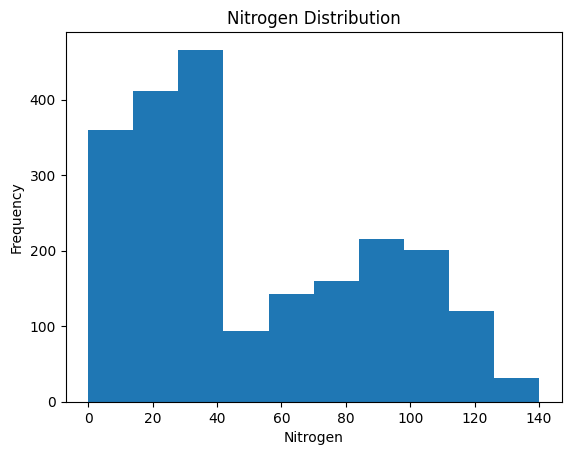

In [8]:
import matplotlib.pyplot as plt

plt.hist(df["N"])
plt.xlabel("Nitrogen")
plt.ylabel("Frequency")
plt.title("Nitrogen Distribution")
plt.show()

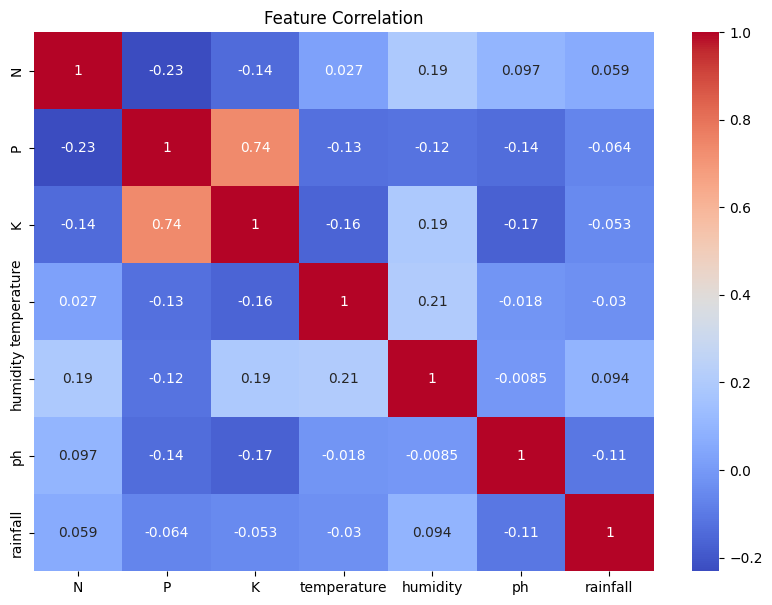

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.drop(columns=["label"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

In [10]:
X = df[
    [
        "N",
        "P",
        "K",
        "temperature",
        "humidity",
        "ph",
        "rainfall"
    ]
]
y = df["label"]

In [11]:
# Encode target labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Crop categories used by the model
print("Crop categories:", list(label_encoder.classes_))

Crop categories: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
predicted_crop = label_encoder.inverse_transform(rf_pred)

print(predicted_crop)

['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange' 'watermelon' 'pomegranate' 'watermelon' 'maize'
 'mothbeans' 'grapes' 'grapes' 'mango' 'mango' 'apple' 'blackgram' 'apple'
 'mothbeans' 'kidneybeans' 'apple' 'jute' 'mothbeans' 'watermelon' 'rice'
 'coffee' 'mango' 'jute' 'banana' 'coffee' 'jute' 'blackgram' 'grapes'
 'grapes' 'blackgram' 'jute' 'coconut' 'papaya' 'mango' 'maize' 'lentil'
 'jute' 'cotton' 'lentil' 'chickpea' 'mungbean' 'papaya' 'pomegranate'
 'pigeonpeas' 'watermelon' 'mango' 'blackgram' 'papaya' 'papaya' 'coffee'
 'lentil' 'lentil' 'mothbeans' 'coffee' 'banana' 'papaya' 'rice' 'orange'
 'coconut' 'blackgram' 'pomegranate' 'banana' 'muskmelon' 'watermelon'
 'lentil' 'banana' 'coconut' 'mothbeans' 'mungbean' 'mungbean' 'mango'
 'coffee' 'watermelon' 'muskmelon' 'kidneybeans' 'mango' 'pomegranate'
 'orange' 'cotton' 'coconut' 'papaya' 'mothbeans' 'mungbean' 'mothbeans'
 'cotton' 'jute' 'grapes' 'cotton' 'chickpea' 'jute' 'waterm

In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_probabilities = xgb.predict_proba(X_test)

print("XGBoost model trained successfully")

XGBoost model trained successfully


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree": [
        accuracy_score(y_test, dt_pred),
        precision_score(y_test, dt_pred, average="weighted", zero_division=0),
        recall_score(y_test, dt_pred, average="weighted", zero_division=0),
        f1_score(y_test, dt_pred, average="weighted", zero_division=0)
    ],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred, average="weighted", zero_division=0),
        recall_score(y_test, rf_pred, average="weighted", zero_division=0),
        f1_score(y_test, rf_pred, average="weighted", zero_division=0)
    ],
    "XGBoost": [
        accuracy_score(y_test, xgb_pred),
        precision_score(y_test, xgb_pred, average="weighted", zero_division=0),
        recall_score(y_test, xgb_pred, average="weighted", zero_division=0),
        f1_score(y_test, xgb_pred, average="weighted", zero_division=0)
    ]
})

print(metrics_table.to_string(index=False))

   Metric  Decision Tree  Random Forest  XGBoost
 Accuracy       0.979545       0.995455 0.993182
Precision       0.980598       0.995671 0.993703
   Recall       0.979545       0.995455 0.993182
 F1-score       0.979423       0.995452 0.993230


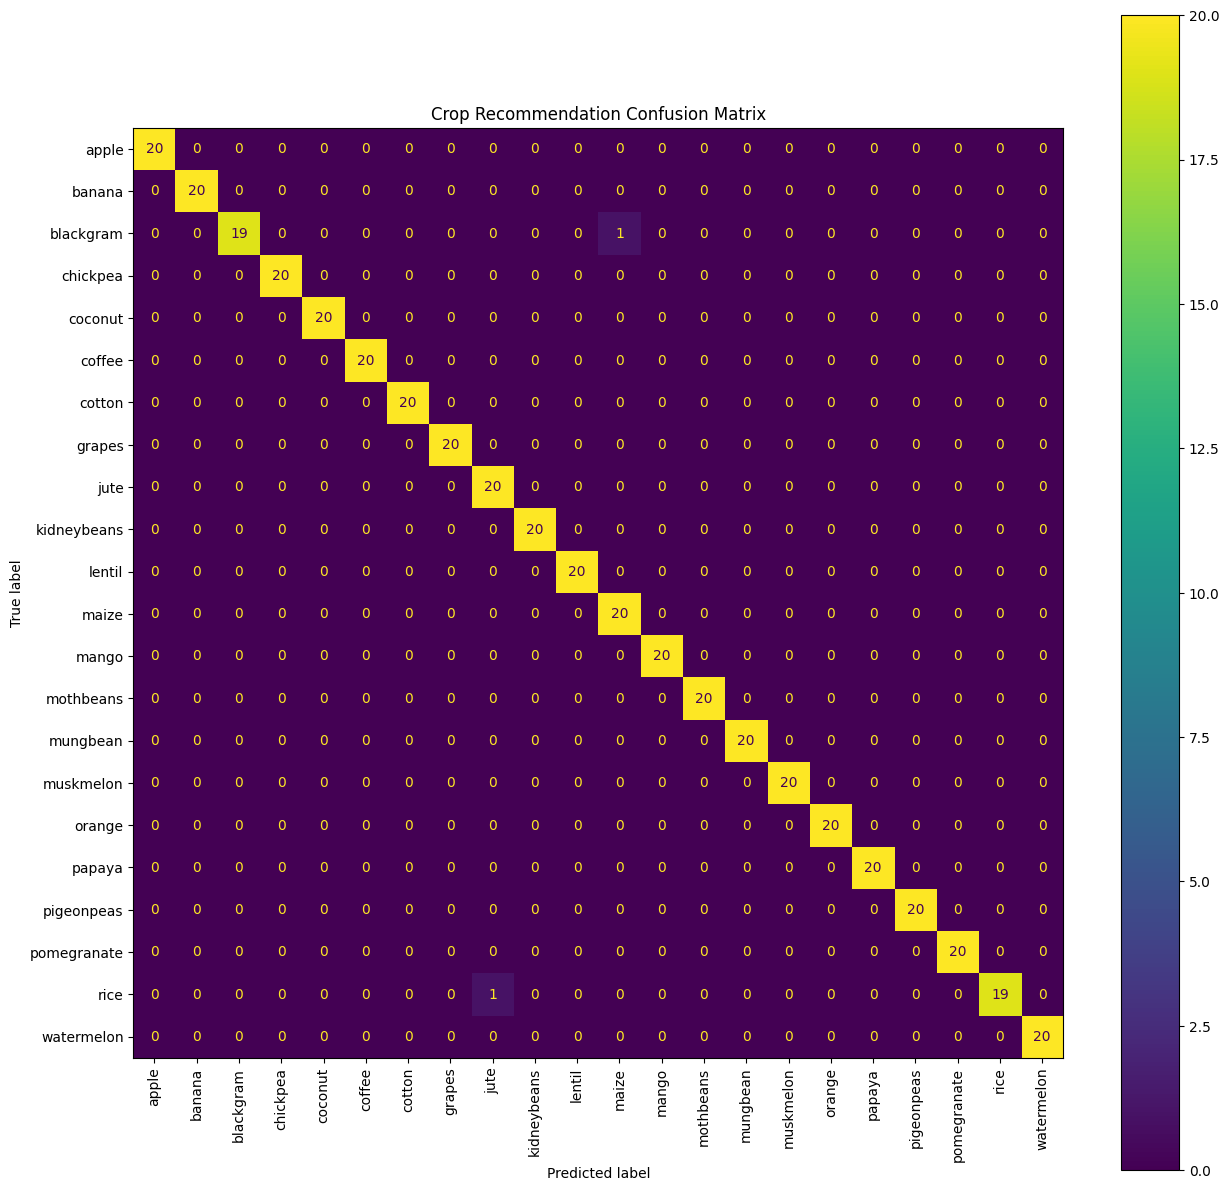

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

_disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(15, 15))

_disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.title("Crop Recommendation Confusion Matrix")
plt.show()

rainfall       0.219641
humidity       0.217058
K              0.180813
P              0.151342
N              0.103356
temperature    0.075485
ph             0.052305
dtype: float64


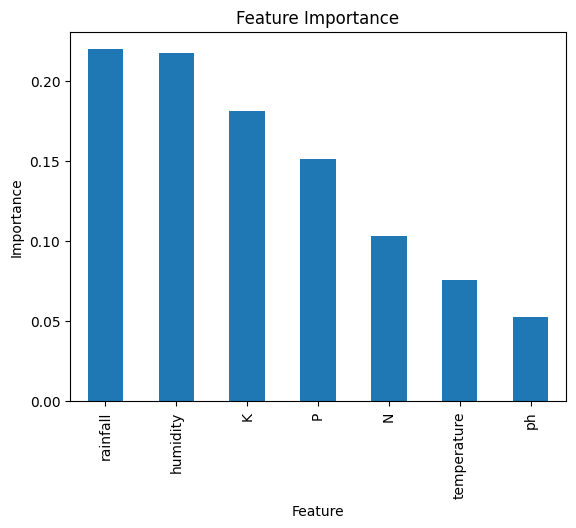

In [19]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)
importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.show()

In [33]:
sample = [[
    2,       # N
    2,       # P
    43,       # K
    9.88,    # temperature
    12.00,    # humidity
    6.50,     # pH
    101.32    # rainfall
]]
prediction = rf.predict(sample)
predicted_crop = label_encoder.inverse_transform(prediction)[0]

print("Recommended Crop:", predicted_crop)

Recommended Crop: kidneybeans


C:\Users\Karrolla Nikhitha\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [34]:
probabilities = rf.predict_proba(sample)
class_numbers = rf.classes_
crop_names = label_encoder.inverse_transform(class_numbers)

results = sorted(
    zip(crop_names, probabilities[0]),
    key=lambda x: x[1],
    reverse=True
)

for crop, score in results[:5]:
    print(crop, round(score * 100, 2), "%")

kidneybeans 36.0 %
chickpea 20.5 %
mango 19.5 %
pomegranate 17.0 %
pigeonpeas 2.0 %


C:\Users\Karrolla Nikhitha\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


   Metric  XGBoost
 Accuracy 0.993182
Precision 0.993703
   Recall 0.993182
 F1-score 0.993230

Classification report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.91      1.00      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon   

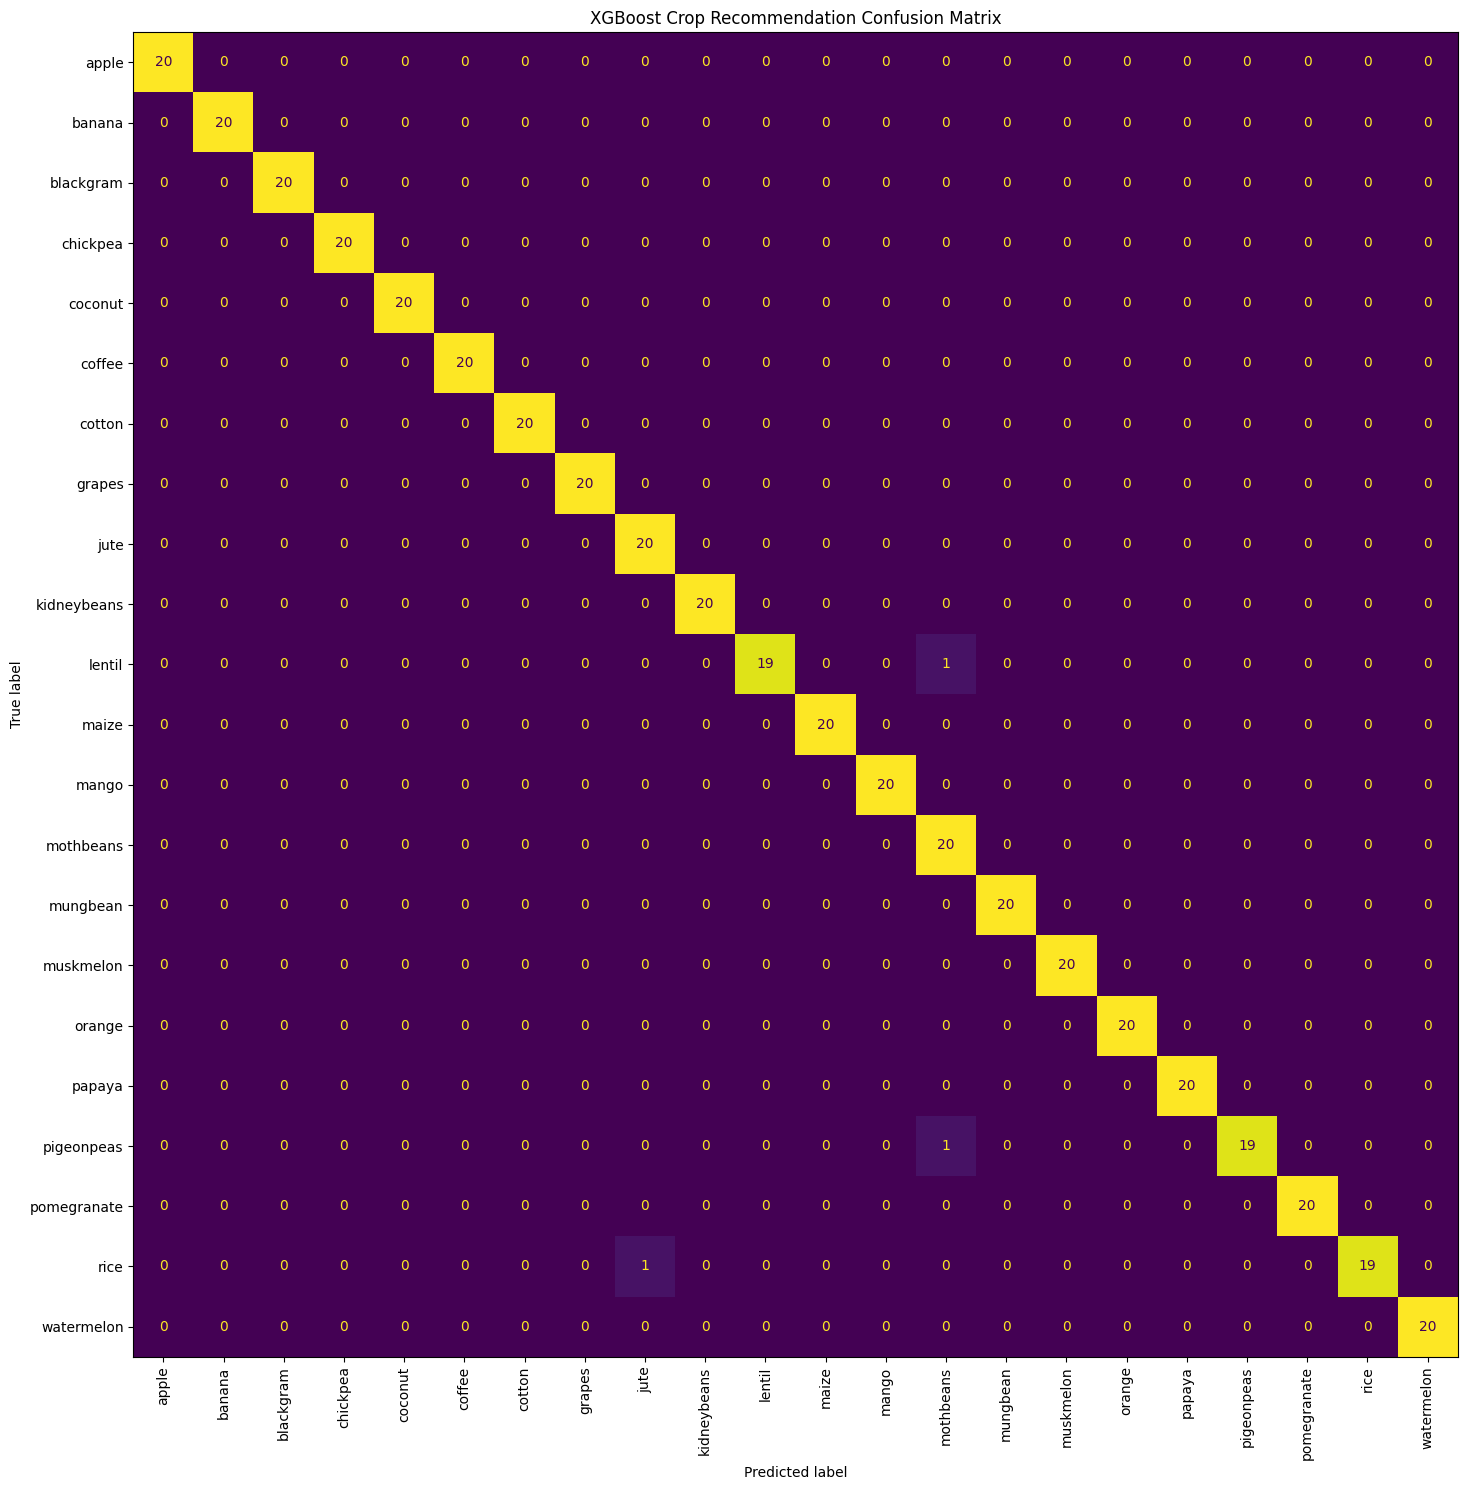

Feature importance:

rainfall       0.187509
humidity       0.176499
P              0.173878
K              0.168737
N              0.131059
temperature    0.094482
ph             0.067836
dtype: float32


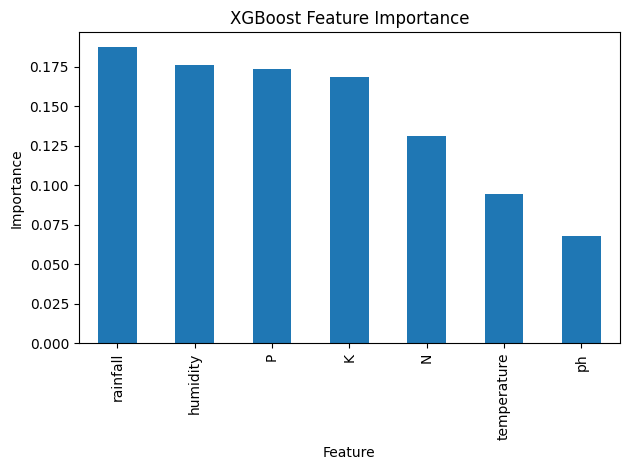

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

xgb_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "XGBoost": [
        accuracy_score(y_test, xgb_pred),
        precision_score(y_test, xgb_pred, average="weighted", zero_division=0),
        recall_score(y_test, xgb_pred, average="weighted", zero_division=0),
        f1_score(y_test, xgb_pred, average="weighted", zero_division=0)
    ]
})

print(xgb_metrics.to_string(index=False))
print("\nClassification report:\n")
print(classification_report(
    y_test,
    xgb_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm = confusion_matrix(y_test, xgb_pred)
fig, ax = plt.subplots(figsize=(15, 15))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("XGBoost Crop Recommendation Confusion Matrix")
plt.tight_layout()
plt.show()

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature importance:\n")
print(xgb_importance)
xgb_importance.plot(kind="bar", title="XGBoost Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [37]:
from pathlib import Path
import joblib

model_dir = Path("../model")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "crop_recommendation_model.pkl"
joblib.dump(rf, model_path)

print(f"Model saved to: {model_path.resolve()}")

Model saved to: C:\Users\Karrolla Nikhitha\OneDrive\Desktop\crop_recommendation\model\crop_recommendation_model.pkl
